In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Multi-eRegulon per cluster + Permutation overlap test
# Inputs:
#   - scplus_obj_geno.pkl
#   - manual_signatures_checkpoint.pkl  (contains tf2g_filtered)
#   - DEG_all_celltypes_KO_vs_Ctrl.csv
# ══════════════════════════════════════════════════════════════════════════════

In [2]:
import os
import re
import pickle
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ── Try the correct SCENICplus scorer (with fallback to pyscenic AUCell) ──────
try:
    from scenicplus.eRegulon_enrichment import score_eRegulons
    SCORE_BACKEND = "scenicplus"
    print("Using scenicplus.eRegulon_enrichment.score_eRegulons")
except ModuleNotFoundError:
    try:
        from scenicplus.eregulon_enrichment import score_eRegulons
        SCORE_BACKEND = "scenicplus"
        print("Using scenicplus.eregulon_enrichment.score_eRegulons")
    except ModuleNotFoundError:
        from ctxcore.genesig import GeneSignature
        from pyscenic.aucell import aucell, create_rankings
        SCORE_BACKEND = "pyscenic"
        print("Falling back to pyscenic AUCell scoring")

Using scenicplus.eregulon_enrichment.score_eRegulons


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
SCPLUS_PKL  = "/Users/cnbr/Downloads/Seurat_scATAC-seq/scenicplus_output/scenicplus/scplus_obj_geno_june_final.pkl"
CHECKPOINT  = "/Users/cnbr/Downloads/Seurat_scATAC-seq/scenicplus_final_output_files/manual_signatures_checkpoint.pkl"
FURTHER_OUT = "/Users/cnbr/Downloads/Seurat_scATAC-seq/scenicplus_output/scenicplus/scenicplus_further_analysis"
DEG_CSV     = os.path.join(FURTHER_OUT, "DEG_KO_vs_Ctrl", "DEG_all_celltypes_KO_vs_Ctrl.csv")
OVERLAP_OUT = os.path.join(FURTHER_OUT, "TF_DEG_overlap")
os.makedirs(OVERLAP_OUT, exist_ok=True)

TOP_N   = 5
N_PERMS = 10000
np.random.seed(42)

In [4]:
print("Loading DEGs...")
deg_all       = pd.read_csv(DEG_CSV)
sig_degs      = deg_all[deg_all["significant"] == True].copy()
sig_degs_up   = sig_degs[sig_degs["log2FC"] > 0]
sig_degs_down = sig_degs[sig_degs["log2FC"] < 0]
print(f"  Total sig DEGs: {len(sig_degs)}")

Loading DEGs...
  Total sig DEGs: 13201


In [5]:
# ── Load objects ──────────────────────────────────────────────────────────────
print("Loading SCENICplus object...")
with open(SCPLUS_PKL, "rb") as f:
    scplus_obj = pickle.load(f)

print("Loading checkpoint...")
with open(CHECKPOINT, "rb") as f:
    checkpoint = pickle.load(f)

tf2g_filtered = checkpoint["tf2g_filtered"]
print(f"  tf2g_filtered shape: {tf2g_filtered.shape}")
print(f"  Columns: {tf2g_filtered.columns.tolist()}")

Loading SCENICplus object...
Loading checkpoint...
  tf2g_filtered shape: (322927, 5)
  Columns: ['TF', 'target', 'importance', 'regulation', 'rho']


In [6]:
# Normalise column names
col_map = {}
for c in tf2g_filtered.columns:
    cl = c.lower()
    if cl in ("target", "gene"):        col_map[c] = "target"
    elif cl == "tf":                     col_map[c] = "TF"
    elif cl == "importance":             col_map[c] = "importance"
    elif cl in ("rho", "correlation"):   col_map[c] = "rho"
tf2g_filtered = tf2g_filtered.rename(columns=col_map)

tf2g_pos = tf2g_filtered[tf2g_filtered["importance"] > 0.0].copy()

In [7]:
import urllib.request

url = "https://raw.githubusercontent.com/aertslab/pySCENIC/master/resources/mm_mgi_tfs.txt"
with urllib.request.urlopen(url, timeout=10) as r:
    known_tfs = set(r.read().decode().strip().split("\n"))
print(f"✅ Loaded {len(known_tfs)} mouse TFs")

# Minimum number of target genes a TF must have to be considered
MIN_TARGETS = 20

# Filter tf2g_pos to only TFs with enough targets
tf_target_counts = tf2g_pos.groupby("TF")["target"].nunique()
valid_tfs = set(tf_target_counts[tf_target_counts >= MIN_TARGETS].index)
print(f"  TFs with >= {MIN_TARGETS} targets: {len(valid_tfs)}")

tf2g_valid = tf2g_pos[tf2g_pos["TF"].isin(valid_tfs)].copy()
# Rebuild tf2g_valid
tf2g_valid = tf2g_pos[
    tf2g_pos["TF"].isin(valid_tfs) &
    tf2g_pos["TF"].isin(known_tfs)
].copy()

print(f"TFs remaining: {tf2g_valid['TF'].nunique()}")
print(f"'Gpam' removed: {'Gpam' not in tf2g_valid['TF'].values}")
print(f"'Spi1' kept:    {'Spi1' in tf2g_valid['TF'].values}")
print(f"'Msi2' kept:    {'Msi2' in tf2g_valid['TF'].values}")

✅ Loaded 1721 mouse TFs
  TFs with >= 20 targets: 1646
TFs remaining: 1520
'Gpam' removed: False
'Spi1' kept:    True
'Msi2' kept:    True


In [8]:
# ── Build specificity-weighted scores across all cell types ───────────────────
print(f"\nBuilding specificity-weighted top-{TOP_N} eRegulons per cluster...")

metadata = scplus_obj.metadata_cell.copy()
expdf    = scplus_obj.to_df("EXP")

MIN_ABSOLUTE_QUANTILE = 0.50

# Step 1: compute weighted scores + log2fc for every cell type
all_ct_scores  = {}
all_ct_tf2g    = {}   # store per-CT tf2g_ct with log2fc for gene picking later

for ct in sorted(metadata["cell_type"].unique()):
    ct_cells = [c for c in metadata[metadata["cell_type"] == ct].index
                if c in expdf.index]
    if len(ct_cells) < 5:
        continue

    ct_exp      = expdf.loc[ct_cells].mean(axis=0)
    other_cells = [c for c in expdf.index if c not in ct_cells]
    other_exp   = expdf.loc[other_cells].mean(axis=0) if other_cells else pd.Series(0, index=expdf.columns)

    tf2g_ct = tf2g_valid.copy()
    tf2g_ct["target_exp"] = tf2g_ct["target"].map(ct_exp).fillna(0)
    tf2g_ct["other_exp"]  = tf2g_ct["target"].map(other_exp).fillna(0)
    tf2g_ct["log2fc"]     = np.log2(
        (tf2g_ct["target_exp"] + 1e-3) / (tf2g_ct["other_exp"] + 1e-3)
    )
    tf2g_ct["weighted"]   = tf2g_ct["importance"] * tf2g_ct["target_exp"]

    all_ct_scores[ct] = tf2g_ct.groupby("TF")["weighted"].sum()
    all_ct_tf2g[ct]   = tf2g_ct   # keep for gene picking in Step 2

scores_df       = pd.DataFrame(all_ct_scores).fillna(0)
mean_across_cts = scores_df.mean(axis=1)

# Step 2: pick top-N TFs by specificity, use CT-enriched gene lists
rows          = []
tf_assignment = {}

for ct in scores_df.columns:
    focal       = scores_df[ct]
    specificity = focal / (mean_across_cts + 1e-9)

    abs_threshold = focal.quantile(MIN_ABSOLUTE_QUANTILE)
    eligible      = specificity[focal >= abs_threshold]
    top_tfs       = eligible.sort_values(ascending=False).head(TOP_N).index.tolist()

    tf2g_ct = all_ct_tf2g[ct]

    for tf in top_tfs:
        sig_name = f"{ct}_pos_manual_{tf}"
        tf_assignment[sig_name] = f"{tf} {ct}"
        top_genes = (
            tf2g_ct[
                (tf2g_ct["TF"] == tf) &
                (tf2g_ct["log2fc"] > 0.5)   # stricter for specificity-weighted
            ]
            .sort_values("weighted", ascending=False)["target"]
            .unique()[:150]
            .tolist()
        )
        if not top_genes:
            print(f"    Warning: no CT-enriched genes (log2fc>0.5) for {tf} in {ct}, skipping")
            continue
        for g in top_genes:
            rows.append({
                "Gene_signature_name":   sig_name,
                "Gene":                  g,
                "Region_signature_name": sig_name,
                "Region":                g,
            })

    print(f"  {ct}: {top_tfs}")

df_multi = pd.DataFrame(rows)
print(f"\nTotal signatures: {df_multi['Gene_signature_name'].nunique()}")


Building specificity-weighted top-5 eRegulons per cluster...
  Astrocytes: ['Gli3', 'Rfx4', 'Gpam', 'Msi1', 'Prdm16']
  Deep-layer extratelencephalic neurons: ['Neurod1', 'Otx1', 'Ckmt1', 'Fezf2', 'Nr4a1']
  Endothelial cells: ['Zfp366', 'Mecom', 'Tbx1', 'Lef1', 'Sox18']
  Layer 2/3 IT neurons: ['Neurod1', 'Barx2', 'Dnajc21', 'Pparg', 'Lhx2']
  Layer 4 sensory neurons: ['Ovol2', 'Barx2', 'Neurod1', 'Dnajc21', 'Pparg']
  Layer 5/6 IT neurons: ['Osr1', 'Pou6f2', 'Ovol2', 'Egr1', 'Egr3']
  Layer 5a IT neurons: ['Neurod1', 'Barx2', 'Lhx2', 'Pparg', 'Emx1']
  Layer 5b PT neurons: ['Etv1', 'Nxph3', 'Hmga2', 'Tceal3', 'Otx1']
  Layer 6a corticothalamic neurons: ['Egr1', 'Pou6f2', 'Tbr1', 'Foxp2', 'Zfp831']
  Layer 6b neurons: ['Nr4a2', 'Pou6f2', 'Sox11', 'Nxph3', 'Ssbp3']
  Meningeal fibroblasts: ['Zic4', 'Tbx15', 'Tbx18', 'Zic1', 'Prdm6']
  Microglia: ['Spi1', 'Zfp710', 'Ikzf1', 'Irf5', 'Irf8']
  Oligodendrocyte precursor cells: ['E2f8', 'Rfx4', 'Traf4', 'Msi1', 'Prrx1']
  Oligodendrocytes:

In [9]:
# ── Score eRegulons ───────────────────────────────────────────────────────────
print("\nScoring eRegulons (AUC)...")
auc_result_spec = score_eRegulons(
    eRegulons        = df_multi,
    gex_mtx          = scplus_obj.to_df("EXP"),
    acc_mtx          = scplus_obj.to_df("ACC"),
    auc_threshold    = 0.05,
    normalize        = False,
    n_cpu            = 4,
)
scplus_obj.uns["eRegulon_AUC_multi_spec"] = auc_result_spec
auc_gb_spec = auc_result_spec["Gene_based"]
print(f"  AUC matrix shape: {auc_gb_spec.shape}")


Scoring eRegulons (AUC)...


Less than 80% of the genes in Astrocytes_pos_manual_Gli3 are present in the expression matrix.
Less than 80% of the genes in Layer 4 sensory neurons_pos_manual_Neurod1 are present in the expression matrix.
Less than 80% of the genes in Astrocytes_pos_manual_Gpam are present in the expression matrix.
Less than 80% of the genes in Layer 4 sensory neurons_pos_manual_Ovol2 are present in the expression matrix.
Less than 80% of the genes in Astrocytes_pos_manual_Msi1 are present in the expression matrix.
Less than 80% of the genes in Layer 6a corticothalamic neurons_pos_manual_Zfp831 are present in the expression matrix.
Less than 80% of the genes in Layer 4 sensory neurons_pos_manual_Pparg are present in the expression matrix.
Less than 80% of the genes in Astrocytes_pos_manual_Prdm16 are present in the expression matrix.
Less than 80% of the genes in Oligodendrocytes_pos_manual_Klf12 are present in the expression matrix.
Less than 80% of the genes in Layer 6b neurons_pos_manual_Nr4a2 are 

  AUC matrix shape: (2446, 85)


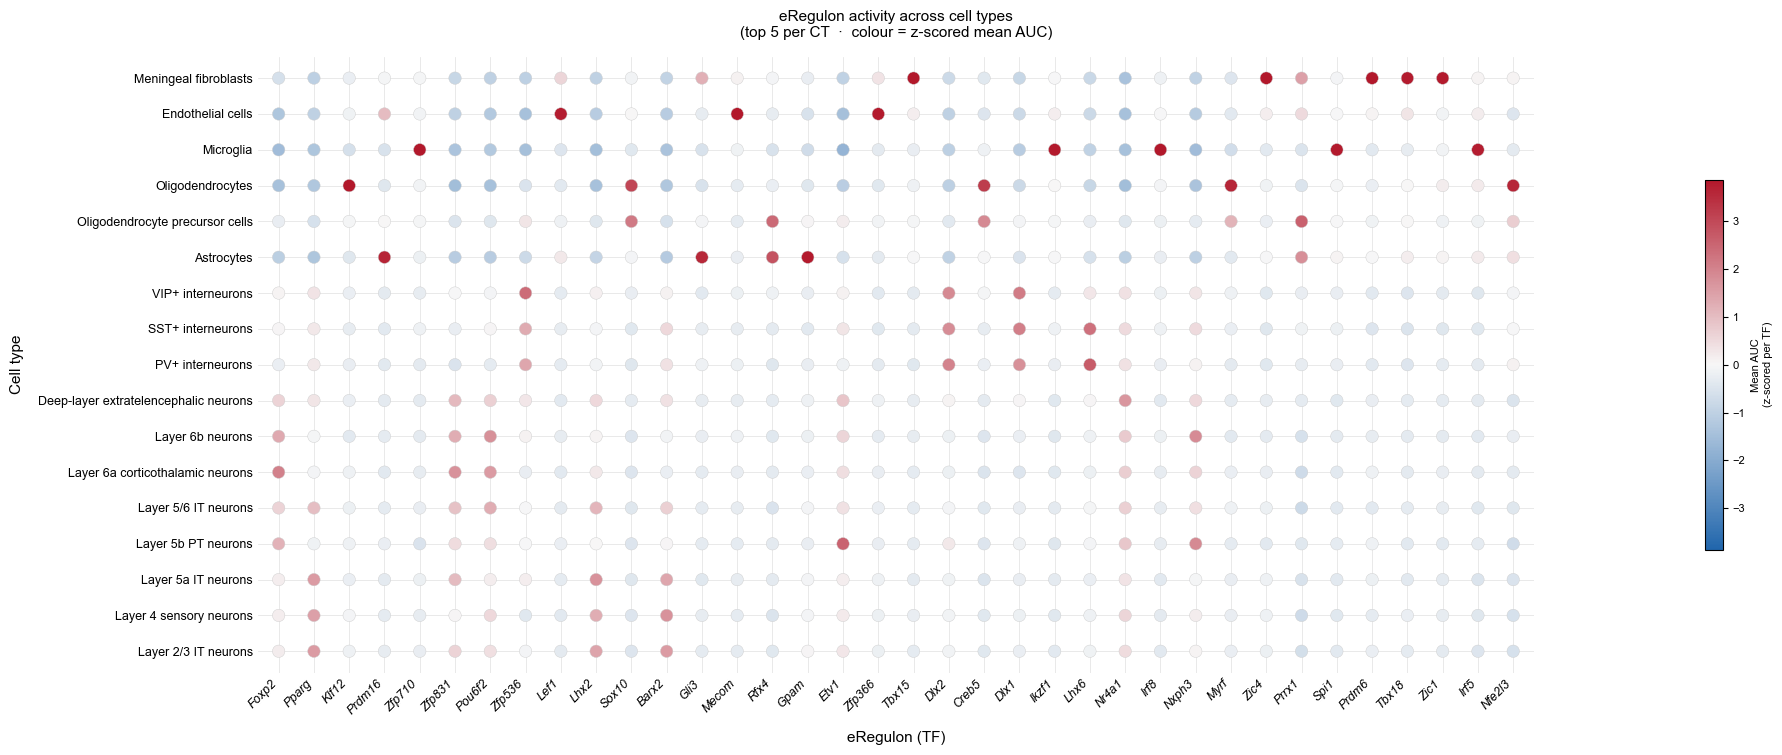

Saved → /Users/cnbr/Downloads/Seurat_scATAC-seq/scenicplus_output/scenicplus/scenicplus_further_analysis/eRegulon_dotplot_exploration.pdf


In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# ── Parameters ─────────────────────────────────────────────────────────────────
DOTPLOT_TOP_N   = 5
MIN_PCT_CELLS   = 0.05
AUC_THRESHOLD   = 0.0
DOT_SIZE        = 80   # fixed size for all dots

# ── Load explicitly from stored result ────────────────────────────────────────
auc_gb = scplus_obj.uns["eRegulon_AUC_multi_spec"]["Gene_based"]
auc_df = auc_gb.copy()

cell_meta = scplus_obj.metadata_cell[["cell_type"]].copy()
auc_df = auc_df.join(cell_meta, how="inner")

# ── Compute per-CT mean AUC and % active cells ─────────────────────────────────
sig_cols = [c for c in auc_df.columns if c != "cell_type"]

records = []
for ct, grp in auc_df.groupby("cell_type"):
    for sig in sig_cols:
        vals = grp[sig].values
        mean_auc   = vals.mean()
        pct_active = (vals > AUC_THRESHOLD).mean()
        tf     = sig.split("_pos_manual_")[-1] if "_pos_manual_" in sig else sig
        sig_ct = sig.split("_pos_manual_")[0].replace("_", " ") if "_pos_manual_" in sig else ""
        records.append({
            "cell_type": ct, "signature": sig,
            "TF": tf, "sig_ct": sig_ct,
            "mean_auc": mean_auc, "pct_active": pct_active,
        })

plot_df = pd.DataFrame(records)

# ── Select top-N TFs per cell type ────────────────────────────────────────────
top_sigs = (
    plot_df.groupby("cell_type")
    .apply(lambda x: x.nlargest(DOTPLOT_TOP_N, "mean_auc"))
    .reset_index(drop=True)
)
keep_sigs = top_sigs["signature"].unique()
plot_df   = plot_df[plot_df["signature"].isin(keep_sigs)].copy()

# ── Pivot ──────────────────────────────────────────────────────────────────────
pivot_mean = plot_df.pivot_table(index="cell_type", columns="TF",
                                  values="mean_auc",   aggfunc="mean").fillna(0)
pivot_pct  = plot_df.pivot_table(index="cell_type", columns="TF",
                                  values="pct_active", aggfunc="mean").fillna(0)

# ── Cell type order ────────────────────────────────────────────────────────────
ct_order = [
    "Layer 2/3 IT neurons", "Layer 4 sensory neurons",
    "Layer 5a IT neurons", "Layer 5b PT neurons", "Layer 5/6 IT neurons",
    "Layer 6a corticothalamic neurons", "Layer 6b neurons",
    "Deep-layer extratelencephalic neurons",
    "PV+ interneurons", "SST+ interneurons", "VIP+ interneurons",
    "Astrocytes", "Oligodendrocyte precursor cells",
    "Oligodendrocytes", "Microglia",
    "Endothelial cells", "Meningeal fibroblasts",
]
ct_order  = [c for c in ct_order if c in pivot_mean.index]
ct_order += [c for c in pivot_mean.index if c not in ct_order]

pivot_mean = pivot_mean.loc[ct_order]
pivot_pct  = pivot_pct.loc[ct_order]

# ── TF order: by variance (most specific first) ────────────────────────────────
tf_order   = pivot_mean.var(axis=0).sort_values(ascending=False).index.tolist()
pivot_mean = pivot_mean[tf_order]
pivot_pct  = pivot_pct[tf_order]

# ── Z-score per TF across CTs ─────────────────────────────────────────────────
pivot_z = pivot_mean.apply(lambda col: (col - col.mean()) / (col.std() + 1e-9), axis=0)
abs_max = np.abs(pivot_z.values).max()
norm    = mcolors.Normalize(vmin=-abs_max, vmax=abs_max)

# ── Colormap: blue → white → red ──────────────────────────────────────────────
cmap = mcolors.LinearSegmentedColormap.from_list(
    "KO_diff", ["#2166ac", "#f7f7f7", "#b2182b"]
)
abs_max = np.abs(pivot_z.values).max()
norm    = mcolors.Normalize(vmin=-abs_max, vmax=abs_max)   # symmetric around 0 → white = average

# ── Plot ───────────────────────────────────────────────────────────────────────
n_ct  = len(pivot_mean.index)
n_tf  = len(pivot_mean.columns)
fig_w = max(14, n_tf * 0.55)
fig_h = max(6,  n_ct * 0.45)

plt.rcParams["font.family"] = "Arial"

fig, ax = plt.subplots(figsize=(fig_w, fig_h))

xs, ys, colours = [], [], []
for i, ct in enumerate(pivot_mean.index):
    for j, tf in enumerate(pivot_mean.columns):
        if pivot_pct.loc[ct, tf] < MIN_PCT_CELLS:
            continue
        xs.append(j)
        ys.append(i)
        colours.append(cmap(norm(pivot_z.loc[ct, tf])))

ax.scatter(xs, ys, s=DOT_SIZE, c=colours,
           linewidths=0.3, edgecolors="#cccccc", zorder=3)

ax.set_xticks(range(n_tf))
ax.set_yticks(range(n_ct))
ax.set_xticklabels(pivot_mean.columns, rotation=45, ha="right",
                   fontsize=9, fontstyle="italic")
ax.set_yticklabels(pivot_mean.index, fontsize=9)
ax.set_xlim(-0.6, n_tf - 0.4)
ax.set_ylim(-0.6, n_ct - 0.4)
ax.grid(True, color="#e0e0e0", linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xlabel("eRegulon (TF)", fontsize=11, labelpad=10)
ax.set_ylabel("Cell type", fontsize=11, labelpad=10)
ax.set_title(
    f"eRegulon activity across cell types\n"
    f"(top {DOTPLOT_TOP_N} per CT  ·  colour = z-scored mean AUC)",
    fontsize=11, pad=14
)

# ── Colorbar ───────────────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.1, aspect=20)
cbar.set_label("Mean AUC\n(z-scored per TF)", fontsize=8)
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
out_path = os.path.join(FURTHER_OUT, "eRegulon_dotplot_exploration.pdf")
plt.savefig(out_path, bbox_inches="tight", dpi=600)
plt.savefig(out_path.replace(".pdf", ".png"), bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved → {out_path}")

In [21]:
# # ── Export TF–target CSVs (one per TF × cell type) ───────────────────────────
# csv_dir = os.path.join(FURTHER_OUT, "TF_target_csvs_multi")
# os.makedirs(csv_dir, exist_ok=True)

# csv_files = []  # used by permutation loop below

# for sig_name, label in tf_assignment.items():
#     tf_name = label.split(" ")[0]
#     # extract cell type: everything after "tf_name "
#     ct_name = " ".join(label.split(" ")[1:])

#     sub = df_multi[df_multi["Gene_signature_name"] == sig_name][["Gene"]].copy()
#     sub = sub.rename(columns={"Gene": "target"})

#     # Add rho from tf2g_filtered to allow rho>0 filtering in permutation
#     rho_map = (tf2g_filtered[tf2g_filtered["TF"] == tf_name]
#                .set_index("target")["rho"]
#                .to_dict())
#     sub["rho"] = sub["target"].map(rho_map).fillna(0)

#     safe_ct = re.sub(r"[^A-Za-z0-9_\-]+", "_", ct_name)
#     safe_tf = re.sub(r"[^A-Za-z0-9_\-]+", "_", tf_name)
#     out_path = os.path.join(csv_dir, f"{safe_tf}__{safe_ct}.csv")
#     sub.to_csv(out_path, index=False)
#     csv_files.append((tf_name, ct_name, out_path))

# print(f"Exported {len(csv_files)} TF×CT target CSVs.")

Exported 85 TF×CT target CSVs.


In [12]:
# Quick sanity check before running
print(f"df_multi signatures: {df_multi['Gene_signature_name'].nunique()}")  # should be 85
print(f"Example gene count for Spi1/Microglia:")
print(df_multi[df_multi["Gene_signature_name"] == "Microglia_pos_manual_Spi1"].shape[0])

df_multi signatures: 85
Example gene count for Spi1/Microglia:
150


In [13]:
print(df_multi[df_multi["Gene_signature_name"].str.contains("Layer_2_3.*Neurod1|Neurod1.*Layer")].shape[0])

# Or more directly — check a CT where you'd expect fewer specific genes:
for sig in df_multi["Gene_signature_name"].unique():
    n = df_multi[df_multi["Gene_signature_name"] == sig].shape[0]
    print(f"{sig}: {n} genes")

0
Astrocytes_pos_manual_Gli3: 150 genes
Astrocytes_pos_manual_Rfx4: 150 genes
Astrocytes_pos_manual_Gpam: 150 genes
Astrocytes_pos_manual_Msi1: 94 genes
Astrocytes_pos_manual_Prdm16: 150 genes
Deep-layer extratelencephalic neurons_pos_manual_Neurod1: 19 genes
Deep-layer extratelencephalic neurons_pos_manual_Otx1: 16 genes
Deep-layer extratelencephalic neurons_pos_manual_Ckmt1: 50 genes
Deep-layer extratelencephalic neurons_pos_manual_Fezf2: 85 genes
Deep-layer extratelencephalic neurons_pos_manual_Nr4a1: 67 genes
Endothelial cells_pos_manual_Zfp366: 140 genes
Endothelial cells_pos_manual_Mecom: 142 genes
Endothelial cells_pos_manual_Tbx1: 73 genes
Endothelial cells_pos_manual_Lef1: 150 genes
Endothelial cells_pos_manual_Sox18: 45 genes
Layer 2/3 IT neurons_pos_manual_Neurod1: 17 genes
Layer 2/3 IT neurons_pos_manual_Barx2: 61 genes
Layer 2/3 IT neurons_pos_manual_Dnajc21: 97 genes
Layer 2/3 IT neurons_pos_manual_Pparg: 150 genes
Layer 2/3 IT neurons_pos_manual_Lhx2: 74 genes
Layer 4 se

In [14]:
# ── Export TF–target CSVs (one per TF × cell type) ───────────────────────────
csv_dir = os.path.join(FURTHER_OUT, "TF_target_csvs_multi_spec")
os.makedirs(csv_dir, exist_ok=True)

csv_files = []  # used by permutation loop below

for sig_name, label in tf_assignment.items():
    tf_name = label.split(" ")[0]
    # extract cell type: everything after "tf_name "
    ct_name = " ".join(label.split(" ")[1:])

    sub = df_multi[df_multi["Gene_signature_name"] == sig_name][["Gene"]].copy()
    sub = sub.rename(columns={"Gene": "target"})

    # Add rho from tf2g_filtered to allow rho>0 filtering in permutation
    rho_map = (tf2g_filtered[tf2g_filtered["TF"] == tf_name]
               .set_index("target")["rho"]
               .to_dict())
    sub["rho"] = sub["target"].map(rho_map).fillna(0)

    safe_ct = re.sub(r"[^A-Za-z0-9_\-]+", "_", ct_name)
    safe_tf = re.sub(r"[^A-Za-z0-9_\-]+", "_", tf_name)
    out_path = os.path.join(csv_dir, f"{safe_tf}__{safe_ct}.csv")
    sub.to_csv(out_path, index=False)
    csv_files.append((tf_name, ct_name, out_path))

print(f"Exported {len(csv_files)} TF×CT target CSVs.")

Exported 85 TF×CT target CSVs.


In [15]:
# ── Permutation overlap test ───────────────────────────────────────────────────
print(f"\nRunning permutation overlap test (N={N_PERMS})...")

overlap_rows = []

for tf_name, ct_name, csv_path in csv_files:
    tf_df      = pd.read_csv(csv_path)
    tf_targets = set(tf_df[tf_df["rho"] > 0]["target"].dropna().astype(str).str.strip())

    ct_bg_list   = list(deg_all[deg_all["cell_type"] == ct_name]["gene"].astype(str))
    ct_bg_set    = set(ct_bg_list)
    ct_degs_all  = set(sig_degs[sig_degs["cell_type"] == ct_name]["gene"].astype(str))
    ct_degs_up   = set(sig_degs_up[sig_degs_up["cell_type"] == ct_name]["gene"].astype(str))
    ct_degs_down = set(sig_degs_down[sig_degs_down["cell_type"] == ct_name]["gene"].astype(str))

    tf_targets_tested = tf_targets & ct_bg_set

    if not ct_bg_list or not tf_targets_tested:
        continue

    ct_bg_arr = np.array(ct_bg_list)
    indices   = np.arange(len(ct_bg_arr))

    for direction, ct_degs_set in [("All", ct_degs_all),
                                    ("Up",  ct_degs_up),
                                    ("Down", ct_degs_down)]:
        n_degs    = len(ct_degs_set)
        n_targets = len(tf_targets_tested)
        n_bg      = len(ct_bg_arr)

        if n_degs == 0 or n_targets == 0:
            continue

        observed = len(tf_targets_tested & ct_degs_set)

        null_overlaps = np.zeros(N_PERMS, dtype=int)
        for i in range(N_PERMS):
            perm_degs = set(ct_bg_arr[np.random.choice(indices, size=n_degs, replace=False)])
            null_overlaps[i] = len(tf_targets_tested & perm_degs)

        pval             = (np.sum(null_overlaps >= observed) + 1) / (N_PERMS + 1)
        enrichment_ratio = observed / (null_overlaps.mean() + 1e-9)

        overlap_rows.append({
            "TF":               tf_name,
            "Cell_Type":        ct_name,
            "Direction":        direction,
            "N_TF_Targets":     n_targets,
            "N_DEGs":           n_degs,
            "N_Overlap":        observed,
            "Expected_Overlap": round(null_overlaps.mean(), 2),
            "Enrichment_Ratio": round(enrichment_ratio, 3),
            "Perm_Pval":        round(pval, 5),
            "Overlap_Genes":    ",".join(sorted(tf_targets_tested & ct_degs_set)),
        })
        print(f"  {tf_name} | {ct_name} | {direction}: "
              f"obs={observed}, exp={null_overlaps.mean():.1f}, "
              f"ratio={enrichment_ratio:.2f}, p={pval:.4f}")


Running permutation overlap test (N=10000)...
  Gli3 | Astrocytes | All: obs=38, exp=21.9, ratio=1.74, p=0.0001
  Gli3 | Astrocytes | Up: obs=14, exp=8.5, ratio=1.64, p=0.0318
  Gli3 | Astrocytes | Down: obs=24, exp=13.4, ratio=1.80, p=0.0014
  Rfx4 | Astrocytes | All: obs=38, exp=24.8, ratio=1.53, p=0.0001
  Rfx4 | Astrocytes | Up: obs=20, exp=9.6, ratio=2.08, p=0.0004
  Rfx4 | Astrocytes | Down: obs=18, exp=15.1, ratio=1.19, p=0.2275
  Gpam | Astrocytes | All: obs=44, exp=26.2, ratio=1.68, p=0.0001
  Gpam | Astrocytes | Up: obs=17, exp=10.2, ratio=1.67, p=0.0173
  Gpam | Astrocytes | Down: obs=27, exp=16.0, ratio=1.69, p=0.0005
  Msi1 | Astrocytes | All: obs=13, exp=7.3, ratio=1.78, p=0.0031
  Msi1 | Astrocytes | Up: obs=8, exp=2.8, ratio=2.83, p=0.0034
  Msi1 | Astrocytes | Down: obs=5, exp=4.4, ratio=1.13, p=0.4661
  Prdm16 | Astrocytes | All: obs=44, exp=22.7, ratio=1.94, p=0.0001
  Prdm16 | Astrocytes | Up: obs=14, exp=8.8, ratio=1.59, p=0.0418
  Prdm16 | Astrocytes | Down: obs=

In [16]:
# ── FDR correction + save ─────────────────────────────────────────────────────
perm_df = pd.DataFrame(overlap_rows)
_, perm_df["Perm_FDR"], _, _ = multipletests(perm_df["Perm_Pval"], method="fdr_bh")
perm_df = perm_df.sort_values("Perm_Pval")

out_csv = os.path.join(OVERLAP_OUT, "TF_DEG_overlap_permutation_KO_vs_Ctrl_multi_eRegulon_spec.csv")
perm_df.to_csv(out_csv, index=False)
print(f"\n✅ Permutation done. Results saved to:\n   {out_csv}")

sig_all = perm_df[(perm_df["Direction"] == "All") & (perm_df["Perm_FDR"] < 0.05)]
sig_dir = perm_df[(perm_df["Direction"] != "All") & (perm_df["Perm_FDR"] < 0.05)]
print(f"\nSignificant (Direction=All, FDR<0.05):        {len(sig_all)}")
print(f"Significant (Direction=Up/Down, FDR<0.05):    {len(sig_dir)}")
print("\nTop hits:")
print(perm_df[perm_df["Perm_FDR"] < 0.05][
    ["TF", "Cell_Type", "Direction", "N_Overlap",
     "Expected_Overlap", "Enrichment_Ratio", "Perm_Pval", "Perm_FDR"]
].to_string(index=False))


✅ Permutation done. Results saved to:
   /Users/cnbr/Downloads/Seurat_scATAC-seq/scenicplus_output/scenicplus/scenicplus_further_analysis/TF_DEG_overlap/TF_DEG_overlap_permutation_KO_vs_Ctrl_multi_eRegulon_spec.csv

Significant (Direction=All, FDR<0.05):        36
Significant (Direction=Up/Down, FDR<0.05):    35

Top hits:
     TF                             Cell_Type Direction  N_Overlap  Expected_Overlap  Enrichment_Ratio  Perm_Pval  Perm_FDR
   Gli3                            Astrocytes       All         38             21.85             1.739     0.0001  0.001232
  Nr4a1 Deep-layer extratelencephalic neurons      Down         19              6.38             2.980     0.0001  0.001232
   Lhx6                      PV+ interneurons       All         13              3.65             3.559     0.0001  0.001232
  Foxp2      Layer 6a corticothalamic neurons       All         52             40.26             1.292     0.0001  0.001232
 Zfp710                             Microglia       Al

In [23]:
# # ── FDR correction + save ─────────────────────────────────────────────────────
# perm_df = pd.DataFrame(overlap_rows)
# _, perm_df["Perm_FDR"], _, _ = multipletests(perm_df["Perm_Pval"], method="fdr_bh")
# perm_df = perm_df.sort_values("Perm_Pval")

# out_csv = os.path.join(OVERLAP_OUT, "TF_DEG_overlap_permutation_KO_vs_Ctrl_multi_eRegulon.csv")
# perm_df.to_csv(out_csv, index=False)
# print(f"\n✅ Permutation done. Results saved to:\n   {out_csv}")

# sig_all = perm_df[(perm_df["Direction"] == "All") & (perm_df["Perm_FDR"] < 0.05)]
# sig_dir = perm_df[(perm_df["Direction"] != "All") & (perm_df["Perm_FDR"] < 0.05)]
# print(f"\nSignificant (Direction=All, FDR<0.05):        {len(sig_all)}")
# print(f"Significant (Direction=Up/Down, FDR<0.05):    {len(sig_dir)}")
# print("\nTop hits:")
# print(perm_df[perm_df["Perm_FDR"] < 0.05][
#     ["TF", "Cell_Type", "Direction", "N_Overlap",
#      "Expected_Overlap", "Enrichment_Ratio", "Perm_Pval", "Perm_FDR"]
# ].to_string(index=False))


✅ Permutation done. Results saved to:
   /Users/cnbr/Downloads/Seurat_scATAC-seq/scenicplus_output/scenicplus/scenicplus_further_analysis/TF_DEG_overlap/TF_DEG_overlap_permutation_KO_vs_Ctrl_multi_eRegulon.csv

Significant (Direction=All, FDR<0.05):        16
Significant (Direction=Up/Down, FDR<0.05):    18

Top hits:
    TF                             Cell_Type Direction  N_Overlap  Expected_Overlap  Enrichment_Ratio  Perm_Pval  Perm_FDR
  Egr3                  Layer 5/6 IT neurons       All         32              8.75             3.657     0.0001  0.002182
  Egr1                  Layer 5/6 IT neurons      Down         24              5.71             4.206     0.0001  0.002182
  Egr1                  Layer 5/6 IT neurons       All         25              8.38             2.983     0.0001  0.002182
  Rfx4                            Astrocytes        Up         11              2.36             4.660     0.0001  0.002182
 Nr4a1 Deep-layer extratelencephalic neurons      Down         2

In [17]:
# ── Build multi-eRegulon signatures (simple weighted, exploration) ────────────
EXPL_TOP_N        = 10
EXPL_MIN_CELLS    = 5
EXPL_TOP_GENES    = 150

print(f"\nBuilding top-{EXPL_TOP_N} eRegulons per cluster (simple weighted, known TFs only)...")

metadata = scplus_obj.metadata_cell.copy()
expdf    = scplus_obj.to_df("EXP")

rows_expl          = []
tf_assignment_expl = {}

for ct in sorted(metadata["cell_type"].unique()):
    ct_cells = [c for c in metadata[metadata["cell_type"] == ct].index
                if c in expdf.index]
    if len(ct_cells) < EXPL_MIN_CELLS:
        print(f"  Skip {ct}: only {len(ct_cells)} cells")
        continue

    ct_exp     = expdf.loc[ct_cells].mean(axis=0)
    other_cells = [c for c in expdf.index if c not in ct_cells]
    other_exp   = expdf.loc[other_cells].mean(axis=0) if other_cells else pd.Series(0, index=expdf.columns)

    tf2g_ct = tf2g_valid.copy()
    tf2g_ct["target_exp"] = tf2g_ct["target"].map(ct_exp).fillna(0)
    tf2g_ct["other_exp"]  = tf2g_ct["target"].map(other_exp).fillna(0)
    tf2g_ct["log2fc"]     = np.log2(
        (tf2g_ct["target_exp"] + 1e-3) / (tf2g_ct["other_exp"] + 1e-3)
    )
    tf2g_ct["weighted"]   = tf2g_ct["importance"] * tf2g_ct["target_exp"]
    tf_scores = tf2g_ct.groupby("TF")["weighted"].sum().sort_values(ascending=False)

    selected = 0
    for tf in tf_scores.index:
        if selected >= EXPL_TOP_N:
            break
        sig_name = f"{ct}_expl_{tf}"
        tf_assignment_expl[sig_name] = f"{tf} {ct}"
        top_genes = (
            tf2g_ct[
                (tf2g_ct["TF"] == tf) &
                (tf2g_ct["log2fc"] > 0)
            ]
            .sort_values("weighted", ascending=False)["target"]
            .unique()[:EXPL_TOP_GENES]
            .tolist()
        )
        if not top_genes:
            print(f"    Warning: no CT-enriched genes for {tf} in {ct}, skipping")
            continue
        for g in top_genes:
            rows_expl.append({
                "Gene_signature_name":   sig_name,
                "Gene":                  g,
                "Region_signature_name": sig_name,
                "Region":                g,
            })
        selected += 1

    print(f"  {ct}: top TFs = {list(tf_scores.index[:EXPL_TOP_N])}")

df_expl = pd.DataFrame(rows_expl)
print(f"\nTotal exploration signatures: {df_expl['Gene_signature_name'].nunique()}")


Building top-10 eRegulons per cluster (simple weighted, known TFs only)...
  Astrocytes: top TFs = ['Rora', 'Msi2', 'Mef2c', 'Zbtb20', 'Thrb', 'Luzp2', 'Npas2', 'Rorb', 'Pbx1', 'Nfia']
  Deep-layer extratelencephalic neurons: top TFs = ['Zbtb20', 'Mef2c', 'Rora', 'Nfia', 'Celf5', 'Zfp831', 'Srrm3', 'Zmat4', 'Bcl11b', 'Thrb']
  Endothelial cells: top TFs = ['Mef2c', 'Zbtb20', 'Rora', 'Fli1', 'Msi2', 'Rbfox2', 'Zeb2', 'Foxp1', 'Epas1', 'Nfia']
  Layer 2/3 IT neurons: top TFs = ['Zbtb20', 'Mef2c', 'Rora', 'Nfia', 'Celf5', 'Srrm3', 'Zfp831', 'Pparg', 'Cux2', 'Zmat4']
  Layer 4 sensory neurons: top TFs = ['Zbtb20', 'Rora', 'Mef2c', 'Nfia', 'Celf5', 'Srrm3', 'Rorb', 'Zmat4', 'Pparg', 'Cux2']
  Layer 5/6 IT neurons: top TFs = ['Zbtb20', 'Mef2c', 'Rora', 'Celf5', 'Nfia', 'Zfp831', 'Srrm3', 'Zmat4', 'Thrb', 'Bcl11b']
  Layer 5a IT neurons: top TFs = ['Zbtb20', 'Mef2c', 'Nfia', 'Rora', 'Celf5', 'Zfp831', 'Srrm3', 'Pparg', 'Cux2', 'Npas2']
  Layer 5b PT neurons: top TFs = ['Zbtb20', 'Mef2c', 'Ce

In [16]:
# ── Score eRegulons ───────────────────────────────────────────────────────────
print("\nScoring eRegulons (AUC)...")
auc_result_expl = score_eRegulons(
    eRegulons        = df_expl,
    gex_mtx          = scplus_obj.to_df("EXP"),
    acc_mtx          = scplus_obj.to_df("ACC"),
    auc_threshold    = 0.05,
    normalize        = False,
    n_cpu            = 4,
)
scplus_obj.uns["eRegulon_AUC_multi_expl"] = auc_result
auc_gb_expl = auc_result_expl["Gene_based"]
print(f"  AUC matrix shape: {auc_gb_expl.shape}")


Scoring eRegulons (AUC)...


Less than 80% of the genes in Astrocytes_expl_Luzp2 are present in the expression matrix.
Less than 80% of the genes in Layer 4 sensory neurons_expl_Nfia are present in the expression matrix.
Less than 80% of the genes in Astrocytes_expl_Mef2c are present in the expression matrix.
Less than 80% of the genes in Layer 4 sensory neurons_expl_Pparg are present in the expression matrix.
Less than 80% of the genes in Layer 6a corticothalamic neurons_expl_Srrm3 are present in the expression matrix.
Less than 80% of the genes in Astrocytes_expl_Msi2 are present in the expression matrix.
Less than 80% of the genes in Layer 4 sensory neurons_expl_Rora are present in the expression matrix.
Less than 80% of the genes in Layer 6a corticothalamic neurons_expl_Zbtb20 are present in the expression matrix.
Less than 80% of the genes in Oligodendrocyte precursor cells_expl_Zfp536 are present in the expression matrix.
Less than 80% of the genes in Astrocytes_expl_Nfia are present in the expression matrix

  AUC matrix shape: (2446, 170)


In [17]:
print(list(auc_gb_expl.columns[:5]))

['Astrocytes_expl_Luzp2', 'Astrocytes_expl_Mef2c', 'Astrocytes_expl_Msi2', 'Astrocytes_expl_Nfia', 'Astrocytes_expl_Npas2']
